# Data Access Auditor

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/access-auditor/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/access-auditor/demo.ipynb)

Answer **"who can see the PII table, and should they?"** in seconds instead of a week of digging. Ingest access grants and get back triaged, *explainable* governance findings - over-privileged access, stale grants, over-exposed sensitive datasets, orphaned grants, and segregation-of-duties conflicts. This is a **defensive least-privilege hygiene** tool: findings are review candidates, not auto-revokes.

**Contents**
1. Why rule-based and explainable
2. A sample grants table with planted risks
3. Run the audit and read the findings
4. Triage rollup + a chart
5. Summary and try-your-own-data


## Step 1 - why rule-based and explainable?

Access review is a governance decision a human has to defend in an audit, so the tool's job is to **surface evidence**, not to score access with an opaque model. Each rule maps to a named least-privilege principle:

- **over-privileged** - least privilege says a role gets the *minimum* access to do its job; write/admin on restricted data by a non-admin role breaks that.
- **stale** - access that hasn't been used in a long time is pure liability; unused grants pile up silently.
- **exposure** - sensitive data should have a small, named audience; too many users on a restricted dataset is over-exposure.
- **orphaned** - some roles (contractor, intern) should never touch restricted data at all; these are usually offboarding leftovers.
- **sod** - segregation of duties stops one person from both performing and checking an action.

Every finding carries the **reason** it fired, which turns a governance alert from "trust me" into "here's the evidence." We keep the reference date fixed and the rng seeded so this notebook is fully reproducible.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd

# --- Tunable governance bar - edit for your own policy tolerance. ---
STALE_DAYS = 90            # a grant unused this long is stale access to review
EXPOSURE_MAX_USERS = 5     # more than this many users on ONE restricted dataset
PRIVILEGED_ROLES = {"data_admin", "dba", "security_admin", "platform_admin"}
DISALLOWED_ON_RESTRICTED = {"contractor", "intern", "guest", "vendor"}
SOD_CONFLICTS = [
    ("data_engineer", "auditor"),      # builds the pipeline AND audits it
    ("payments_admin", "approver"),    # moves money AND signs off on it
]
_SEV_RANK = {"high": 0, "medium": 1, "low": 2}

# Fixed reference date so the audit is reproducible (no datetime.now()).
AS_OF = pd.Timestamp("2026-07-01")


@dataclass
class Finding:
    """One flagged grant (or user-level issue) with the reason it fired."""

    rule: str        # over-privileged | stale | exposure | orphaned | sod
    severity: str    # high | medium | low
    user: str
    dataset: str     # '*' for user-level findings that span datasets
    reason: str


### The five rules

Same logic as `auditor.py`, inlined here so the notebook is self-contained. Each function reads a grants frame and returns explainable `Finding`s.


In [2]:
def _is_restricted(level: str) -> bool:
    return str(level).strip().lower() == "restricted"


def _over_privileged(df: pd.DataFrame) -> List[Finding]:
    # Write/admin on restricted data by a non-privileged role = too much power.
    out: List[Finding] = []
    for _, r in df.iterrows():
        perm = str(r["permission"]).strip().lower()
        role = str(r["role"]).strip().lower()
        if (_is_restricted(r["sensitivity"]) and perm in {"write", "admin"}
                and role not in PRIVILEGED_ROLES):
            sev = "high" if perm == "admin" else "medium"
            out.append(Finding(
                "over-privileged", sev, str(r["user"]), str(r["dataset"]),
                f"role '{role}' holds {perm} on RESTRICTED dataset "
                f"'{r['dataset']}' but is not a privileged role; "
                f"violates least privilege"))
    return out


def _stale(df: pd.DataFrame, as_of: pd.Timestamp) -> List[Finding]:
    # Grants unused for STALE_DAYS - measured vs as_of, never datetime.now().
    out: List[Finding] = []
    for _, r in df.iterrows():
        last = pd.to_datetime(r.get("last_used_date"), errors="coerce")
        ref = last if pd.notna(last) else pd.to_datetime(
            r.get("granted_date"), errors="coerce")
        if pd.isna(ref):
            continue
        days = (as_of - ref).days
        if days >= STALE_DAYS:
            never = "never used" if pd.isna(last) else f"last used {days}d ago"
            sev = "high" if _is_restricted(r["sensitivity"]) else (
                "medium" if days >= STALE_DAYS * 2 else "low")
            out.append(Finding(
                "stale", sev, str(r["user"]), str(r["dataset"]),
                f"grant on '{r['dataset']}' ({r['sensitivity']}) {never}, "
                f">= {STALE_DAYS}d idle bar; candidate to revoke"))
    return out


def _exposure(df: pd.DataFrame) -> List[Finding]:
    # Too many distinct users on ONE restricted dataset = over-exposure.
    out: List[Finding] = []
    restricted = df[df["sensitivity"].astype(str).str.lower() == "restricted"]
    if restricted.empty:
        return out
    for dataset, grp in restricted.groupby("dataset"):
        users = grp["user"].astype(str).nunique()
        if users > EXPOSURE_MAX_USERS:
            sev = "high" if users > EXPOSURE_MAX_USERS * 2 else "medium"
            out.append(Finding(
                "exposure", sev, "*", str(dataset),
                f"{users} distinct users can access RESTRICTED dataset "
                f"'{dataset}' (bar is {EXPOSURE_MAX_USERS}); shrink the audience"))
    return out


def _orphaned(df: pd.DataFrame) -> List[Finding]:
    # Roles that should never touch restricted data (contractors, interns...).
    out: List[Finding] = []
    for _, r in df.iterrows():
        role = str(r["role"]).strip().lower()
        if _is_restricted(r["sensitivity"]) and role in DISALLOWED_ON_RESTRICTED:
            out.append(Finding(
                "orphaned", "high", str(r["user"]), str(r["dataset"]),
                f"role '{role}' should never hold access to RESTRICTED data, "
                f"yet has {str(r['permission']).lower()} on '{r['dataset']}'; "
                f"likely a leftover / offboarding gap"))
    return out


def _sod(df: pd.DataFrame) -> List[Finding]:
    # Segregation-of-duties: one user holding two conflicting roles.
    out: List[Finding] = []
    roles_by_user: Dict[str, set] = {}
    for _, r in df.iterrows():
        roles_by_user.setdefault(str(r["user"]), set()).add(
            str(r["role"]).strip().lower())
    for user, roles in roles_by_user.items():
        for a, b in SOD_CONFLICTS:
            if a in roles and b in roles:
                out.append(Finding(
                    "sod", "high", user, "*",
                    f"user holds conflicting roles '{a}' + '{b}'; "
                    f"segregation-of-duties conflict, split the duties"))
    return out


def audit_grants(df: pd.DataFrame,
                 as_of: Optional[pd.Timestamp] = None) -> List[Finding]:
    # Run every rule. Edge case: empty frame -> no findings.
    if df is None or df.empty:
        return []
    if as_of is None:
        dates = pd.to_datetime(
            pd.concat([df.get("last_used_date"), df.get("granted_date")]),
            errors="coerce")
        as_of = dates.max() if dates.notna().any() else pd.Timestamp.today()
    findings: List[Finding] = []
    findings += _over_privileged(df)
    findings += _stale(df, as_of)
    findings += _exposure(df)
    findings += _orphaned(df)
    findings += _sod(df)
    return findings


def findings_frame(findings: List[Finding]) -> pd.DataFrame:
    cols = ["rule", "severity", "user", "dataset", "reason"]
    rows = [{"rule": f.rule, "severity": f.severity, "user": f.user,
             "dataset": f.dataset, "reason": f.reason} for f in findings]
    df = pd.DataFrame(rows, columns=cols)
    if not df.empty:
        df = df.sort_values("severity", key=lambda s: s.map(_SEV_RANK),
                            kind="stable").reset_index(drop=True)
    return df


def summarize(findings: List[Finding]) -> pd.DataFrame:
    rules = ["over-privileged", "stale", "exposure", "orphaned", "sod"]
    rows = []
    for rule in rules:
        sub = [f for f in findings if f.rule == rule]
        rows.append({"rule": rule, "findings": len(sub),
                     "high": sum(f.severity == "high" for f in sub),
                     "medium": sum(f.severity == "medium" for f in sub),
                     "low": sum(f.severity == "low" for f in sub)})
    return pd.DataFrame(rows)


## Step 2 - a sample grants table with planted risks

So you can watch the auditor earn its keep, we build a small access-grant table and deliberately plant one of each risk:

- **over-privileged** - `grace` (an `analyst`) has `admin` on the restricted `customer_pii` table
- **stale** - `ivan`'s grant is unused for ~200 days; `mallory`'s was never used
- **exposure** - many distinct users all sit on the restricted `customer_pii` dataset
- **orphaned** - `oscar` is a `contractor` with access to restricted data
- **sod** - `peggy` holds both `data_engineer` and `auditor` roles

`heidi` is a legitimate `data_admin` and `trent`/`wendy` are clean - they should *not* be flagged over-privileged, so we can see the tool isn't just flagging everything.


In [3]:
def make_sample_grants(seed: int = 42) -> pd.DataFrame:
    rng = np.random.default_rng(seed)  # seeded for reproducibility
    rows = [
        # user, role, dataset, sensitivity, permission, granted, last_used
        ("alice",   "analyst",       "customer_pii", "restricted", "read",  "2026-05-01", "2026-06-20"),
        ("bob",     "analyst",       "customer_pii", "restricted", "read",  "2026-05-01", "2026-06-18"),
        ("carol",   "analyst",       "customer_pii", "restricted", "read",  "2026-05-02", "2026-06-25"),
        ("dan",     "analyst",       "customer_pii", "restricted", "read",  "2026-05-03", "2026-06-15"),
        ("erin",    "analyst",       "customer_pii", "restricted", "read",  "2026-05-04", "2026-06-10"),
        ("frank",   "analyst",       "customer_pii", "restricted", "read",  "2026-05-05", "2026-06-01"),
        ("grace",   "analyst",       "customer_pii", "restricted", "admin", "2026-04-01", "2026-06-28"),  # over-privileged
        ("heidi",   "data_admin",    "customer_pii", "restricted", "admin", "2026-04-01", "2026-06-29"),  # legit admin
        ("ivan",    "analyst",       "sales_summary", "internal",  "read",  "2025-06-01", "2025-12-13"),  # stale ~200d
        ("judy",    "analyst",       "customer_pii", "restricted", "read",  "2025-05-01", "2025-11-20"),  # stale on restricted
        ("mallory", "analyst",       "billing",      "confidential", "read", "2026-01-01", None),         # never used
        ("oscar",   "contractor",    "customer_pii", "restricted", "read",  "2026-06-01", "2026-06-27"),  # orphaned
        ("peggy",   "data_engineer", "sales_summary", "internal",  "write", "2026-03-01", "2026-06-26"),  # sod (pair 1/2)
        ("peggy",   "auditor",       "audit_log",     "confidential", "read", "2026-03-01", "2026-06-26"),  # sod (pair 2/2)
        ("trent",   "analyst",       "sales_summary", "internal",  "read",  "2026-06-01", "2026-06-28"),  # clean
        ("wendy",   "viewer",        "public_docs",   "public",    "read",  "2026-06-10", "2026-06-30"),  # clean
    ]
    df = pd.DataFrame(rows, columns=[
        "user", "role", "dataset", "sensitivity",
        "permission", "granted_date", "last_used_date"])
    df["granted_date"] = pd.to_datetime(df["granted_date"])
    df["last_used_date"] = pd.to_datetime(df["last_used_date"])
    return df


df = make_sample_grants()
print(f"{len(df)} grants, reference date AS_OF = {AS_OF.date()}")
df


16 grants, reference date AS_OF = 2026-07-01


,user,role,dataset,sensitivity,permission,granted_date,last_used_date
0,alice,analyst,customer_pii,restricted,read,2026-05-01,2026-06-20
1,bob,analyst,customer_pii,restricted,read,2026-05-01,2026-06-18
2,carol,analyst,customer_pii,restricted,read,2026-05-02,2026-06-25
3,dan,analyst,customer_pii,restricted,read,2026-05-03,2026-06-15
4,erin,analyst,customer_pii,restricted,read,2026-05-04,2026-06-10
5,frank,analyst,customer_pii,restricted,read,2026-05-05,2026-06-01
6,grace,analyst,customer_pii,restricted,admin,2026-04-01,2026-06-28
7,heidi,data_admin,customer_pii,restricted,admin,2026-04-01,2026-06-29
8,ivan,analyst,sales_summary,internal,read,2025-06-01,2025-12-13
9,judy,analyst,customer_pii,restricted,read,2025-05-01,2025-11-20


## Step 3 - run the audit and read the findings

`audit_grants()` runs all five rules against the fixed `AS_OF` date. `findings_frame()` returns a flat table sorted most-severe first. Every row is **explainable**: it names the user, the dataset, and the exact reason.


In [4]:
findings = audit_grants(df, as_of=AS_OF)
flat = findings_frame(findings)
pd.set_option("display.max_colwidth", 90)
flat


,rule,severity,user,dataset,reason
0,over-privileged,high,grace,customer_pii,role 'analyst' holds admin on RESTRICTED dataset 'customer_pii' but is not a privilege...
1,stale,high,judy,customer_pii,"grant on 'customer_pii' (restricted) last used 223d ago, >= 90d idle bar; candidate to..."
2,orphaned,high,oscar,customer_pii,"role 'contractor' should never hold access to RESTRICTED data, yet has read on 'custom..."
3,sod,high,peggy,*,user holds conflicting roles 'data_engineer' + 'auditor'; segregation-of-duties confli...
4,stale,medium,ivan,sales_summary,"grant on 'sales_summary' (internal) last used 200d ago, >= 90d idle bar; candidate to ..."
5,stale,medium,mallory,billing,"grant on 'billing' (confidential) never used, >= 90d idle bar; candidate to revoke"
6,exposure,medium,*,customer_pii,10 distinct users can access RESTRICTED dataset 'customer_pii' (bar is 5); shrink the ...


### The triage rollup by rule

`summarize()` gives one row per rule with counts by severity - the steward's at-a-glance view of where the risk concentrates before opening the full list.


In [5]:
summary = summarize(findings)
summary


,rule,findings,high,medium,low
0,over-privileged,1,1,0,0
1,stale,3,1,2,0
2,exposure,1,0,1,0
3,orphaned,1,1,0,0
4,sod,1,1,0,0


## Step 4 - a findings-by-rule chart

A quick stacked bar so the eye lands on the rules carrying the most (and the most severe) findings first.


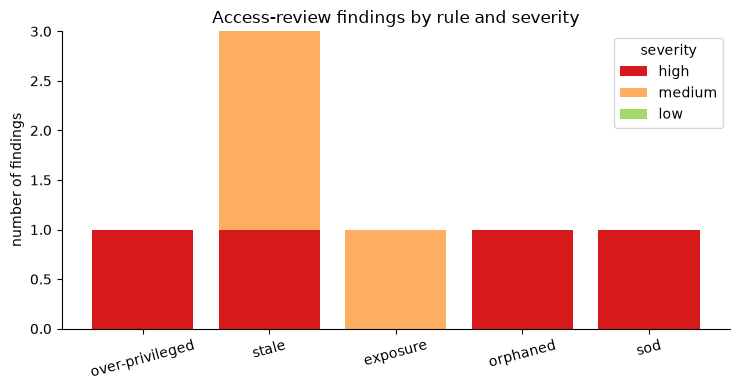

In [6]:
import matplotlib.pyplot as plt

sev_colors = {"high": "#d7191c", "medium": "#fdae61", "low": "#a6d96a"}
plot_df = summary.set_index("rule")[["high", "medium", "low"]]

fig, ax = plt.subplots(figsize=(7.5, 4))
bottom = np.zeros(len(plot_df))
for sev in ["high", "medium", "low"]:
    ax.bar(plot_df.index, plot_df[sev], bottom=bottom,
           label=sev, color=sev_colors[sev])
    bottom += plot_df[sev].values
ax.set_ylabel("number of findings")
ax.set_title("Access-review findings by rule and severity")
ax.legend(title="severity")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("findings_by_rule.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary

The auditor caught **every planted risk** without hand-tuning:

| Rule | Caught |
|------|--------|
| `over-privileged` | `grace` (analyst) with `admin` on restricted `customer_pii` - high |
| `stale` | `judy` (restricted, high), `ivan` (~200d, medium), `mallory` (never used, medium) |
| `exposure` | many distinct users on restricted `customer_pii` - shrink the audience |
| `orphaned` | `oscar` the contractor on restricted data - high |
| `sod` | `peggy` holds `data_engineer` + `auditor` - high |

And it correctly **left the clean grants alone** - `heidi` the legitimate `data_admin`, plus `trent` and `wendy` - so the signal stays trustworthy. The value is not just the flag; it's the **reason** attached to each one, which is what an access review actually needs to act.


## Try your own data

Point it at any grants CSV with columns `user, role, dataset, sensitivity, permission, granted_date, last_used_date`. Uncomment and edit:


In [7]:
# my_df = pd.read_csv("your_grants.csv")
# for c in ("granted_date", "last_used_date"):
#     my_df[c] = pd.to_datetime(my_df[c], errors="coerce")
# my_findings = audit_grants(my_df, as_of=pd.Timestamp("2026-07-01"))  # your audit date
# display(findings_frame(my_findings))
# display(summarize(my_findings))

# Tune the policy bar at the top of the notebook:
#   STALE_DAYS               -> how long unused before a grant is stale
#   EXPOSURE_MAX_USERS       -> audience size that counts as over-exposure
#   PRIVILEGED_ROLES         -> who is allowed write/admin on restricted data
#   DISALLOWED_ON_RESTRICTED -> roles that should never touch restricted data
#   SOD_CONFLICTS            -> role pairs that conflict when one user holds both


---
Part of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) FDE portfolio - Day 95, Data Quality & Governance Suite.

For the interactive app: `streamlit run app.py` in this folder. It lets you upload a grants CSV (or use this sample), audit it, and triage findings by severity. **Findings are hygiene signals for a human access review, not automatic revocation - expect some false positives and confirm with the data owner before removing any access.**
